#بررسی مدل و نتایح inference  ها

In [8]:
!pip install SimpleITK numpy matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 20.1 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [7]:
# مسیر مدل‌های baseline
baseline_dir = '/content/drive/MyDrive/nnUNet_Baseline_Results'

# مسیر مدل‌های pruned
pruned_dir = '/content/drive/MyDrive/nnUNet_Pruned_Results_peds2023'

# مسیر ground truth (labelTs)
ground_truth_dir = '/content/drive/MyDrive/BraTS-peds2023/labelsTs'


In [10]:
!unzip -q "/content/drive/MyDrive/BraTS-peds2023/BraTS-PEDs-2023.zip" -d /content/BraTS_PEDs_2023


In [11]:
import os
import shutil
import glob

source_dir = "/content/BraTS_PEDs_2023/ASNR-MICCAI-BraTS2023-PED-Challenge-TrainingData"
labels_dir = "/content/labelsTs"
os.makedirs(labels_dir, exist_ok=True)

cases = sorted(os.listdir(source_dir))
for case in cases:
    case_path = os.path.join(source_dir, case)
    if not os.path.isdir(case_path):
        continue
    seg_file = glob.glob(os.path.join(case_path, "*seg.nii.gz"))
    if len(seg_file) == 1:
        shutil.copy(seg_file[0], os.path.join(labels_dir, f"{case}.nii.gz"))
    else:
        print(f"Segmentation missing for case: {case}")


🔶 مرحله ۴. بررسی Baseline


In [16]:
import os
import shutil
import glob

# مسیر مبدا
src_baseline = "/content/drive/MyDrive/nnUNet_Baseline_Results/no_TTA"
# مسیر مقصد در Colab
dst_baseline = "/content/baseline_predictions"
os.makedirs(dst_baseline, exist_ok=True)

# کپی همه فایل‌های predicted
for file in glob.glob(os.path.join(src_baseline, "*.nii.gz")):
    shutil.copy(file, dst_baseline)

print(f"✅ همه‌ی predicted های baseline منتقل شدند به: {dst_baseline}")


✅ همه‌ی predicted های baseline منتقل شدند به: /content/baseline_predictions


In [17]:
src_pruned_root = "/content/drive/MyDrive/nnUNet_Pruned_Results_peds2023"
dst_pruned_root = "/content/pruned_predictions"
os.makedirs(dst_pruned_root, exist_ok=True)

# لیست درصدهای pruning
pruned_folders = [
    "BraTS2023_PrunedModel_35percent_inferenceResults",
    "BraTS2023_PrunedModel_50percent_inferenceResults",
    "BraTS2023_PrunedModel_80percent_inferenceResults",
    "BraTS2023_PrunedModel_85percent_inferenceResults",
    "BraTS2023_PrunedModel_90percent_inferenceResults",
    "BraTS2023_PrunedModel_93percent_inferenceResults",
    "BraTS2023_PrunedModel_95percent_inferenceResults",
    "BraTS2023_PrunedModel_97percent_inferenceResults",
    "BraTS2023_PrunedModel_98percent_inferenceResults",
    "BraTS2023_PrunedModel_99percent_inferenceResults"
]

# انتقال فایل‌ها
for folder_name in pruned_folders:
    src_folder = os.path.join(src_pruned_root, folder_name)
    dst_folder = os.path.join(dst_pruned_root, folder_name)
    os.makedirs(dst_folder, exist_ok=True)
    for file in glob.glob(os.path.join(src_folder, "*.nii.gz")):
        shutil.copy(file, dst_folder)
    print(f"✅ فایل‌های {folder_name} منتقل شدند به: {dst_folder}")


✅ فایل‌های BraTS2023_PrunedModel_35percent_inferenceResults منتقل شدند به: /content/pruned_predictions/BraTS2023_PrunedModel_35percent_inferenceResults
✅ فایل‌های BraTS2023_PrunedModel_50percent_inferenceResults منتقل شدند به: /content/pruned_predictions/BraTS2023_PrunedModel_50percent_inferenceResults
✅ فایل‌های BraTS2023_PrunedModel_80percent_inferenceResults منتقل شدند به: /content/pruned_predictions/BraTS2023_PrunedModel_80percent_inferenceResults
✅ فایل‌های BraTS2023_PrunedModel_85percent_inferenceResults منتقل شدند به: /content/pruned_predictions/BraTS2023_PrunedModel_85percent_inferenceResults
✅ فایل‌های BraTS2023_PrunedModel_90percent_inferenceResults منتقل شدند به: /content/pruned_predictions/BraTS2023_PrunedModel_90percent_inferenceResults
✅ فایل‌های BraTS2023_PrunedModel_93percent_inferenceResults منتقل شدند به: /content/pruned_predictions/BraTS2023_PrunedModel_93percent_inferenceResults
✅ فایل‌های BraTS2023_PrunedModel_95percent_inferenceResults منتقل شدند به: /content/prun

🔶 مرحله ۴ – بارگذاری Ground Truth


In [18]:
import glob
import os

labels_dir = "/content/labelsTs"
gt_files = sorted(glob.glob(os.path.join(labels_dir, "*.nii.gz")))

print(f"✅ تعداد ground truthها: {len(gt_files)}")


✅ تعداد ground truthها: 99


🔶 مرحله ۵ – تعریف تابع محاسبه Dice و HD


In [19]:
import numpy as np
import SimpleITK as sitk
from scipy.spatial.distance import directed_hausdorff

def compute_dice(pred, gt):
    intersection = np.sum((pred > 0) & (gt > 0))
    sum_pred_gt = np.sum(pred > 0) + np.sum(gt > 0)
    if sum_pred_gt == 0:
        return 1.0  # اگر segmentation خالی باشد
    return 2.0 * intersection / sum_pred_gt

def compute_hausdorff(pred, gt):
    pred_points = np.argwhere(pred > 0)
    gt_points = np.argwhere(gt > 0)
    if pred_points.shape[0] == 0 or gt_points.shape[0] == 0:
        return np.nan
    hd1 = directed_hausdorff(pred_points, gt_points)[0]
    hd2 = directed_hausdorff(gt_points, pred_points)[0]
    return max(hd1, hd2)


🔶 مرحله ۶ – محاسبه Baseline


In [20]:
baseline_dir = "/content/baseline_predictions"

dice_scores_baseline = []
hd_scores_baseline = []

for gt_file in gt_files:
    case_id = os.path.basename(gt_file).replace(".nii.gz", "")
    pred_file = os.path.join(baseline_dir, f"{case_id}.nii.gz")

    if not os.path.exists(pred_file):
        print(f"⚠️ Prediction برای {case_id} پیدا نشد.")
        continue

    gt_img = sitk.ReadImage(gt_file)
    pred_img = sitk.ReadImage(pred_file)

    gt_array = sitk.GetArrayFromImage(gt_img)
    pred_array = sitk.GetArrayFromImage(pred_img)

    dice = compute_dice(pred_array, gt_array)
    hd = compute_hausdorff(pred_array, gt_array)

    dice_scores_baseline.append(dice)
    hd_scores_baseline.append(hd)

print(f"✅ Dice میانگین baseline: {np.nanmean(dice_scores_baseline):.4f}")
print(f"✅ HD میانگین baseline: {np.nanmean(hd_scores_baseline):.4f}")


✅ Dice میانگین baseline: 0.8866
✅ HD میانگین baseline: 27.7252


In [21]:
pruned_root_dir = "/content/pruned_predictions"
pruned_results = {}

for folder_name in pruned_folders:
    model_dir = os.path.join(pruned_root_dir, folder_name)
    dice_scores = []
    hd_scores = []

    for gt_file in gt_files:
        case_id = os.path.basename(gt_file).replace(".nii.gz", "")
        pred_file = os.path.join(model_dir, f"{case_id}.nii.gz")

        if not os.path.exists(pred_file):
            print(f"⚠️ Prediction برای {case_id} در {folder_name} پیدا نشد.")
            continue

        gt_img = sitk.ReadImage(gt_file)
        pred_img = sitk.ReadImage(pred_file)

        gt_array = sitk.GetArrayFromImage(gt_img)
        pred_array = sitk.GetArrayFromImage(pred_img)

        dice = compute_dice(pred_array, gt_array)
        hd = compute_hausdorff(pred_array, gt_array)

        dice_scores.append(dice)
        hd_scores.append(hd)

    pruned_results[folder_name] = {
        "dice_mean": np.nanmean(dice_scores),
        "hd_mean": np.nanmean(hd_scores)
    }

print("✅ همه نتایج محاسبه شدند.")


✅ همه نتایج محاسبه شدند.


In [22]:
print("\n🔎 نتایج:")
print(f"{'Model':45s} | {'Dice Mean':10s} | {'HD Mean'}")
print("-"*70)
print(f"{'Baseline':45s} | {np.nanmean(dice_scores_baseline):.4f}     | {np.nanmean(hd_scores_baseline):.4f}")
for folder_name, result in pruned_results.items():
    print(f"{folder_name:45s} | {result['dice_mean']:.4f}     | {result['hd_mean']:.4f}")



🔎 نتایج:
Model                                         | Dice Mean  | HD Mean
----------------------------------------------------------------------
Baseline                                      | 0.8866     | 27.7252
BraTS2023_PrunedModel_35percent_inferenceResults | 0.8866     | 27.7255
BraTS2023_PrunedModel_50percent_inferenceResults | 0.8866     | 27.9448
BraTS2023_PrunedModel_80percent_inferenceResults | 0.8881     | 28.0015
BraTS2023_PrunedModel_85percent_inferenceResults | 0.8801     | 28.8900
BraTS2023_PrunedModel_90percent_inferenceResults | 0.8739     | 31.2212
BraTS2023_PrunedModel_93percent_inferenceResults | 0.8689     | 32.0863
BraTS2023_PrunedModel_95percent_inferenceResults | 0.8541     | 35.9117
BraTS2023_PrunedModel_97percent_inferenceResults | 0.8224     | 41.6196
BraTS2023_PrunedModel_98percent_inferenceResults | 0.8055     | 45.8372
BraTS2023_PrunedModel_99percent_inferenceResults | 0.7622     | 57.1635


📊 مرحله ۱ — ساخت DataFrame:


In [24]:
import re
import pandas as pd

# ابتدا baseline
results = [{
    'Model': 'Baseline',
    'Pruning Level': 0,
    'Dice Mean': np.nanmean(dice_scores_baseline),
    'HD Mean': np.nanmean(hd_scores_baseline)
}]

# سپس pruned models
for folder_name, result in pruned_results.items():
    match = re.search(r'(\d+)percent', folder_name)
    pruning_level = int(match.group(1)) if match else 0
    results.append({
        'Model': folder_name,
        'Pruning Level': pruning_level,
        'Dice Mean': result['dice_mean'],
        'HD Mean': result['hd_mean']
    })

# ساخت DataFrame
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Pruning Level').reset_index(drop=True)

print(results_df)


                                               Model  Pruning Level  \
0                                           Baseline              0   
1   BraTS2023_PrunedModel_35percent_inferenceResults             35   
2   BraTS2023_PrunedModel_50percent_inferenceResults             50   
3   BraTS2023_PrunedModel_80percent_inferenceResults             80   
4   BraTS2023_PrunedModel_85percent_inferenceResults             85   
5   BraTS2023_PrunedModel_90percent_inferenceResults             90   
6   BraTS2023_PrunedModel_93percent_inferenceResults             93   
7   BraTS2023_PrunedModel_95percent_inferenceResults             95   
8   BraTS2023_PrunedModel_97percent_inferenceResults             97   
9   BraTS2023_PrunedModel_98percent_inferenceResults             98   
10  BraTS2023_PrunedModel_99percent_inferenceResults             99   

    Dice Mean    HD Mean  
0    0.886575  27.725202  
1    0.886588  27.725522  
2    0.886648  27.944770  
3    0.888079  28.001485  
4    0.88005

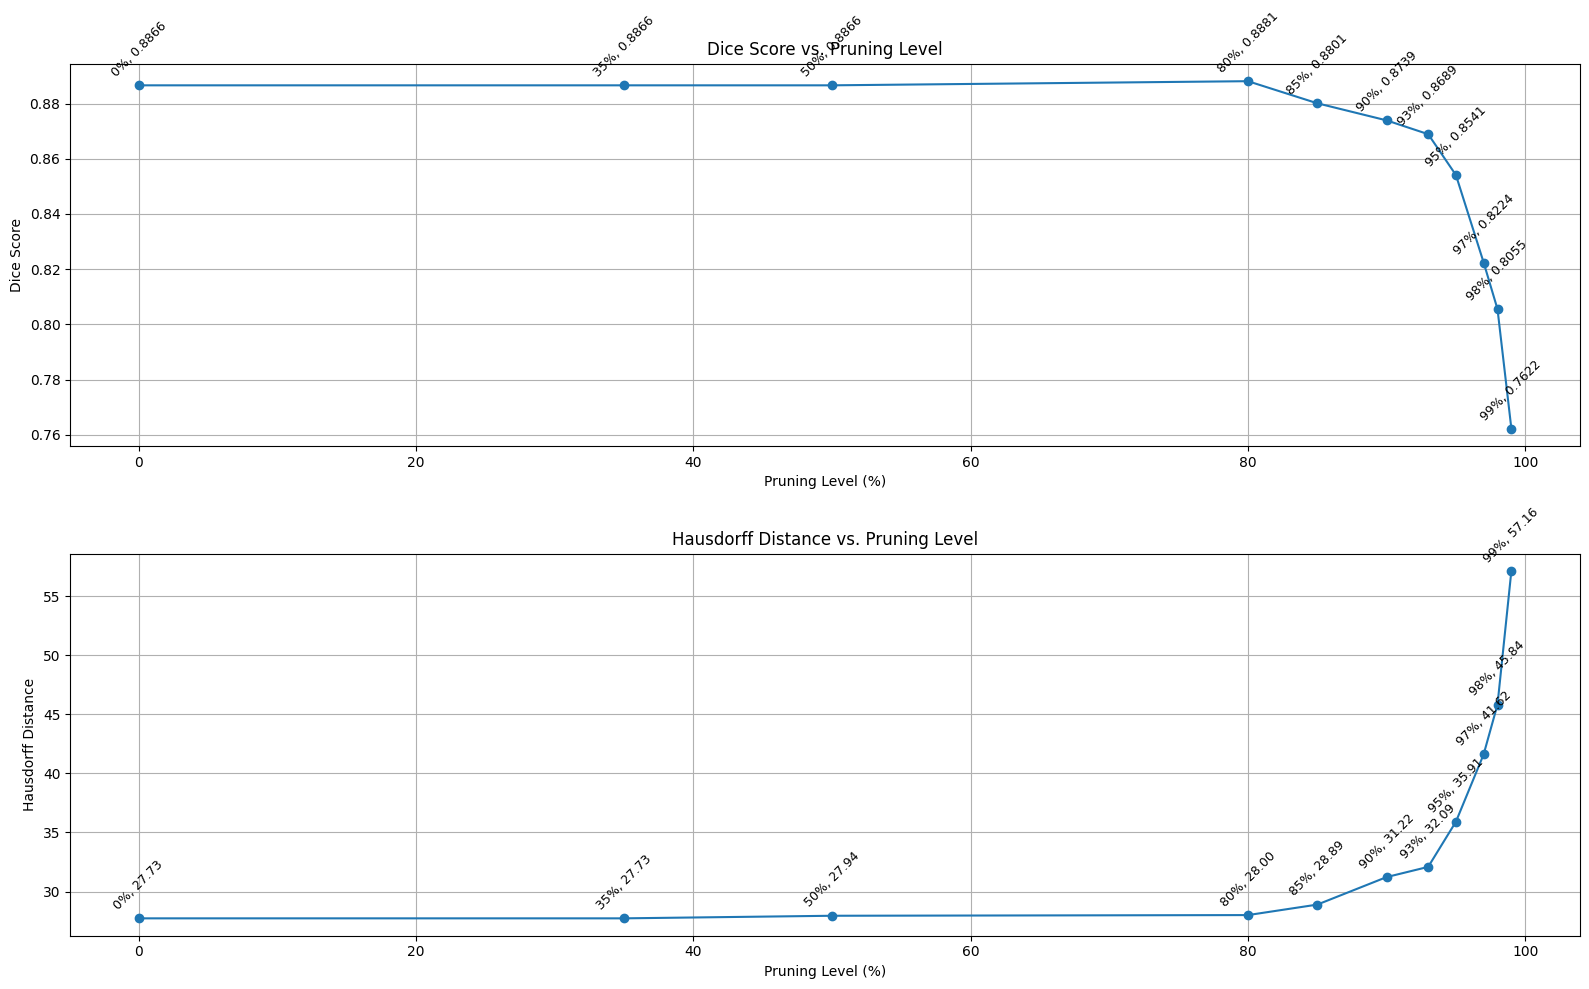

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 10))


# Pruning levels extracted from directory names dynamically earlier
pruning_levels = [0, 35, 50, 80, 85, 90, 93, 95, 97, 98, 99]
dice_means = [0.8866, 0.8866, 0.8866, 0.8881, 0.8801, 0.8739, 0.8689, 0.8541, 0.8224, 0.8055, 0.7622]
hd_means = [27.7252, 27.7255, 27.9448, 28.0015, 28.8900, 31.2212, 32.0863, 35.9117, 41.6196, 45.8372, 57.1635]




# Dice
plt.subplot(2, 1, 1)
plt.plot(pruning_levels, dice_means, marker='o')
for x, y in zip(pruning_levels, dice_means):
    plt.text(x, y + 0.002, f"{x}%, {y:.4f}", ha='center', va='bottom', fontsize=9, rotation=45)
plt.xlabel('Pruning Level (%)')
plt.ylabel('Dice Score')
plt.title('Dice Score vs. Pruning Level')
plt.grid(True)

# HD
plt.subplot(2, 1, 2)
plt.plot(pruning_levels, hd_means, marker='o')
for x, y in zip(pruning_levels, hd_means):
    plt.text(x, y + 0.5, f"{x}%, {y:.2f}", ha='center', va='bottom', fontsize=9, rotation=45)
plt.xlabel('Pruning Level (%)')
plt.ylabel('Hausdorff Distance')
plt.title('Hausdorff Distance vs. Pruning Level')
plt.grid(True)

plt.tight_layout()
plt.show()
